In [4]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress
from sklearn.preprocessing import MinMaxScaler

,name
0,02_nav_history_clean
1,07_scheme_performance_clean
2,08_investor_transactions_clean


In [2]:
conn = sqlite3.connect('../data/bluestock_mf.db')

In [5]:
pd.read_sql(
"""
SELECT name
FROM sqlite_master
WHERE type='table'
""",
conn
)

,name
0,02_nav_history_clean
1,07_scheme_performance_clean
2,08_investor_transactions_clean


In [8]:
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(
    ['amfi_code', 'date']
)

df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [11]:
df['daily_return'] = (
    df.groupby('amfi_code')['nav']
      .pct_change()
)

df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [12]:
df.isnull().sum()

amfi_code        0
date             0
nav              0
daily_return    40
dtype: int64

In [13]:
df['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

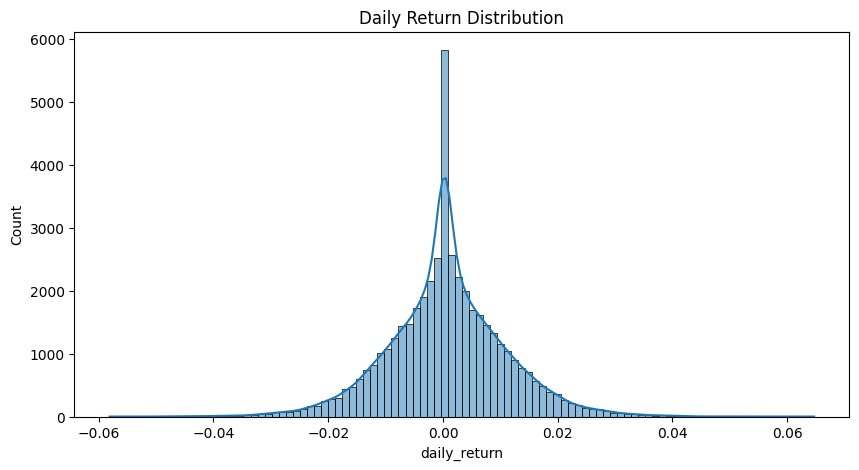

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    df['daily_return'].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")

plt.show()

In [15]:
def calculate_cagr(data, years):

    end_date = data['date'].max()

    start_date = (
        end_date -
        pd.DateOffset(years=years)
    )

    subset = data[
        data['date'] >= start_date
    ]

    if len(subset) < 2:
        return np.nan

    start_nav = subset.iloc[0]['nav']
    end_nav = subset.iloc[-1]['nav']

    return (
        (end_nav / start_nav)
        ** (1 / years)
        - 1
    )

In [16]:
cagr_results = []

for code, grp in df.groupby('amfi_code'):

    cagr_results.append({

        'amfi_code': code,

        'cagr_1y':
        calculate_cagr(grp,1),

        'cagr_3y':
        calculate_cagr(grp,3),

        'cagr_5y':
        calculate_cagr(grp,5)

    })

cagr_df = pd.DataFrame(
    cagr_results
)

cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [17]:
rf = 0.065

def sharpe_ratio(returns):

    annual_return = (
        returns.mean()*252
    )

    annual_std = (
        returns.std()*np.sqrt(252)
    )

    return (
        annual_return-rf
    ) / annual_std

In [18]:
sharpe_results = []

for code, grp in df.groupby('amfi_code'):

    sharpe_results.append({

        'amfi_code': code,

        'sharpe':
        sharpe_ratio(
            grp['daily_return'].dropna()
        )

    })

sharpe_df = pd.DataFrame(
    sharpe_results
)

sharpe_df.sort_values(
    'sharpe',
    ascending=False
).head()

,amfi_code,sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [19]:
cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [20]:
sharpe_df.sort_values(
    'sharpe',
    ascending=False
).head()

,amfi_code,sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [21]:
def sortino_ratio(returns):

    downside = returns[returns < 0]

    downside_std = (
        downside.std() *
        np.sqrt(252)
    )

    annual_return = (
        returns.mean() * 252
    )

    return (
        annual_return - 0.065
    ) / downside_std

In [22]:
sortino_results = []

for code, grp in df.groupby('amfi_code'):

    sortino_results.append({
        'amfi_code': code,
        'sortino': sortino_ratio(
            grp['daily_return'].dropna()
        )
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df.sort_values(
    'sortino',
    ascending=False
).head()

,amfi_code,sortino
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [23]:
def max_drawdown(nav):

    running_max = nav.cummax()

    drawdown = (
        nav / running_max
    ) - 1

    return drawdown.min()

In [24]:
drawdown_results = []

for code, grp in df.groupby('amfi_code'):

    drawdown_results.append({

        'amfi_code': code,

        'max_drawdown':
        max_drawdown(
            grp['nav']
        )

    })

drawdown_df = pd.DataFrame(
    drawdown_results
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [25]:
scorecard = (
    cagr_df
    .merge(sharpe_df,
           on='amfi_code')
    .merge(sortino_df,
           on='amfi_code')
    .merge(drawdown_df,
           on='amfi_code')
)

In [26]:
scorecard['return_rank'] = (
    scorecard['cagr_3y']
    .rank()
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe']
    .rank()
)

scorecard['drawdown_rank'] = (
    (-scorecard['max_drawdown'])
    .rank()
)

In [27]:
scorecard['score'] = (

      0.50 *
      scorecard['return_rank']

    + 0.30 *
      scorecard['sharpe_rank']

    + 0.20 *
      scorecard['drawdown_rank']

)

In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(
    feature_range=(0,100)
)

scorecard['score'] = (
    scaler.fit_transform(
        scorecard[['score']]
    )
)

In [29]:
import os

os.makedirs(
    '../outputs',
    exist_ok=True
)

In [30]:
scorecard.to_csv(
    '../outputs/fund_scorecard.csv',
    index=False
)

print("Saved Successfully")

Saved Successfully


In [31]:
import os

os.listdir('../data')

['bluestock_mf.db', 'processed', 'raw']

In [32]:
import os

print("RAW:")
print(os.listdir('../data/raw'))

print("\nPROCESSED:")
print(os.listdir('../data/processed'))

RAW:
['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip.csv', 'HDFC_Top100.csv', 'ICICI_Bluechip.csv', 'Kotak_Bluechip.csv', 'Nippon_LargeCap.csv', 'SBI_Bluechip.csv']

PROCESSED:
['02_nav_history_clean.csv', '07_scheme_performance_clean.csv', '08_investor_transactions_clean.csv']


In [33]:
benchmark = pd.read_csv('../data/raw/10_benchmark_indices.csv')

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [34]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [35]:
benchmark.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   object 
 1   index_name   8050 non-null   object 
 2   close_value  8050 non-null   float64
dtypes: float64(1), object(2)
memory usage: 188.8+ KB


In [36]:
benchmark['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [37]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100['date'] = pd.to_datetime(
    nifty100['date']
)

nifty100 = nifty100.sort_values(
    'date'
)

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [38]:
from scipy.stats import linregress

def alpha_beta(
    fund_returns,
    benchmark_returns
):

    merged = pd.concat(
        [fund_returns,
         benchmark_returns],
        axis=1
    ).dropna()

    if len(merged) < 30:
        return np.nan, np.nan

    beta, alpha_daily, _, _, _ = (
        linregress(
            merged.iloc[:,1],
            merged.iloc[:,0]
        )
    )

    alpha_annual = (
        alpha_daily * 252
    )

    return alpha_annual, beta

In [39]:
alpha_beta_results = []

benchmark_series = (
    nifty100
    .set_index('date')
    ['benchmark_return']
)

for code, grp in df.groupby('amfi_code'):

    fund_returns = (
        grp.set_index('date')
        ['daily_return']
    )

    alpha, beta = alpha_beta(
        fund_returns,
        benchmark_series
    )

    alpha_beta_results.append({

        'amfi_code': code,
        'alpha': alpha,
        'beta': beta

    })

alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [40]:
alpha_beta_df.to_csv(
    '../outputs/alpha_beta.csv',
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [41]:
scorecard = scorecard.merge(
    alpha_beta_df,
    on='amfi_code'
)

In [42]:
scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank()
)

scorecard['score'] = (

      0.30 *
      scorecard['return_rank']

    + 0.25 *
      scorecard['sharpe_rank']

    + 0.20 *
      scorecard['alpha_rank']

    + 0.25 *
      scorecard['drawdown_rank']

)

In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(
    feature_range=(0,100)
)

scorecard['score'] = (
    scaler.fit_transform(
        scorecard[['score']]
    )
)

In [44]:
top5 = scorecard.sort_values(
    'score',
    ascending=False
)

top5.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y,sharpe,sortino,max_drawdown,return_rank,sharpe_rank,drawdown_rank,score,alpha,beta,alpha_rank
25,120505,0.296047,0.317775,0.283768,1.180101,2.029353,-0.181885,36.0,36.0,25.0,100.000000,0.292636,0.000549,38.0
39,149324,0.651387,0.270004,0.279174,0.949796,1.619793,-0.311719,31.0,28.0,37.0,98.981324,0.300579,0.011455,39.0
16,119094,0.222611,0.351118,0.244453,0.998231,1.703797,-0.209609,40.0,30.0,28.0,97.453311,0.260767,-0.066265,32.0
21,119598,0.827761,0.266699,0.280332,0.945308,1.675317,-0.287060,29.0,27.0,36.0,95.925297,0.303370,-0.023196,40.0
36,148569,0.397518,0.291789,0.276299,1.234930,2.146914,-0.163967,33.0,38.0,21.0,94.567063,0.282704,0.018134,37.0


In [45]:
def tracking_error(
    fund_return,
    benchmark_return
):

    merged = pd.concat(
        [fund_return,
         benchmark_return],
        axis=1
    ).dropna()

    diff = (
        merged.iloc[:,0]
        - merged.iloc[:,1]
    )

    return (
        diff.std()
        * np.sqrt(252)
    )

In [46]:
tracking_results = []

for code, grp in df.groupby('amfi_code'):

    fund_returns = (
        grp.set_index('date')
        ['daily_return']
    )

    te = tracking_error(
        fund_returns,
        benchmark_series
    )

    tracking_results.append({

        'amfi_code': code,
        'tracking_error': te

    })

tracking_df = pd.DataFrame(
    tracking_results
)

tracking_df.head()

,amfi_code,tracking_error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


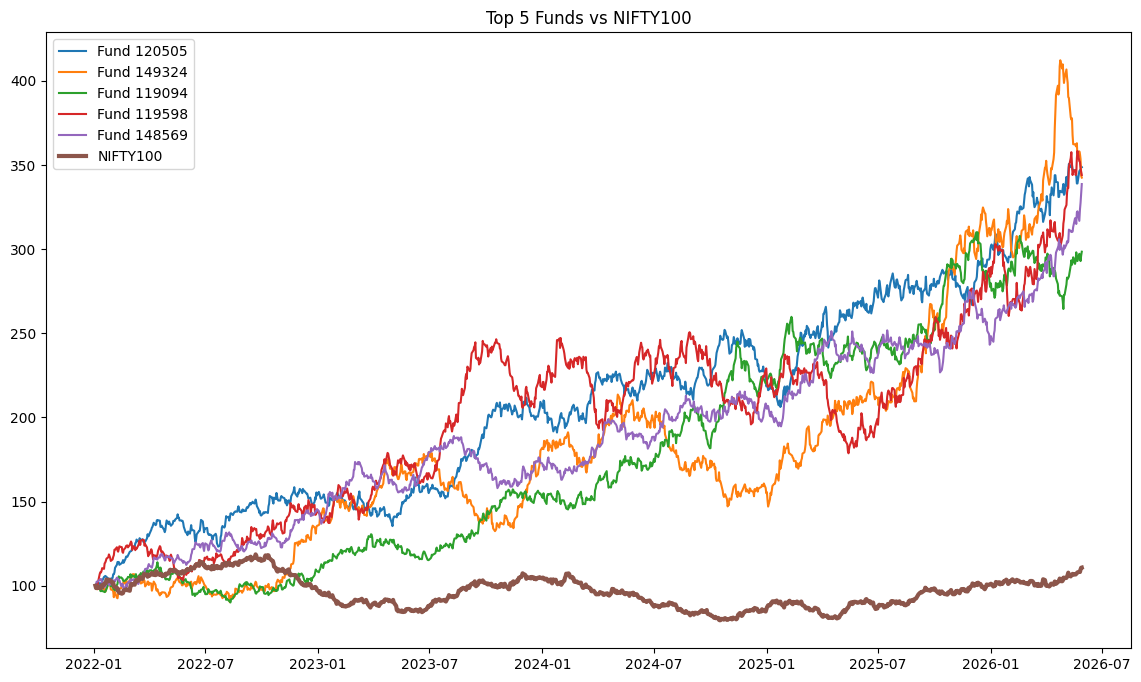

In [47]:
plt.figure(figsize=(14,8))

for code in top5.head(5)['amfi_code']:

    temp = df[
        df['amfi_code'] == code
    ]

    normalized = (
        temp['nav']
        / temp['nav'].iloc[0]
    ) * 100

    plt.plot(
        temp['date'],
        normalized,
        label=f'Fund {code}'
    )

benchmark_norm = (
    nifty100['close_value']
    / nifty100['close_value'].iloc[0]
) * 100

plt.plot(
    nifty100['date'],
    benchmark_norm,
    linewidth=3,
    label='NIFTY100'
)

plt.title(
    'Top 5 Funds vs NIFTY100'
)

plt.legend()

plt.savefig(
    '../outputs/benchmark_comparison.png'
)

plt.show()

In [48]:
scorecard.to_csv(
    '../outputs/fund_scorecard.csv',
    index=False
)

print("Final scorecard saved")

Final scorecard saved
